## RBF RA

In [156]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from RAHelper import *
from rbf.pde.nodes import poisson_disc_nodes

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [157]:
#params
delta = 0.1
K = 64
n = np.floor(K/4)
m = K - n

In [158]:
vert = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
edges = np.array([[0, 1], [1, 2], [2, 3], [3, 0]])
nodes, groups, _ = poisson_disc_nodes(delta, (vert, edges))

In [159]:
#Eval points
X, Y = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
eval_points = np.vstack([X.flatten(), Y.flatten()]).T

In [160]:
#Interpolated function is f(x, y) = sin(pi*x)*sin(pi*y)
f = np.sin(np.pi * nodes[:, 0]) * np.sin(np.pi * nodes[:, 1])

In [161]:
#r = sqrt(x^2 + y^2) => r*Er = sqrt(x^2 + y^2)*Er = sqrt((Er*x)^2 + (Er*y)^2) = sqrt((x')^2 + (y')^2) = r'
Er = GenEr(nodes)
scaled_nodes = Er*nodes
scaled_eval_points = Er*eval_points

es = GenEs(K)
samples = InterpolatedSamples(scaled_nodes, scaled_eval_points, f, es)

fj_mat = np.array(samples)
a, b  = GenRAab(fj_mat, es, n, m)
eval_eps = np.linspace(0, 2, 101)/Er
S = EvalRA(a, b, eval_eps)
S = S[:, 0].reshape(X.shape)


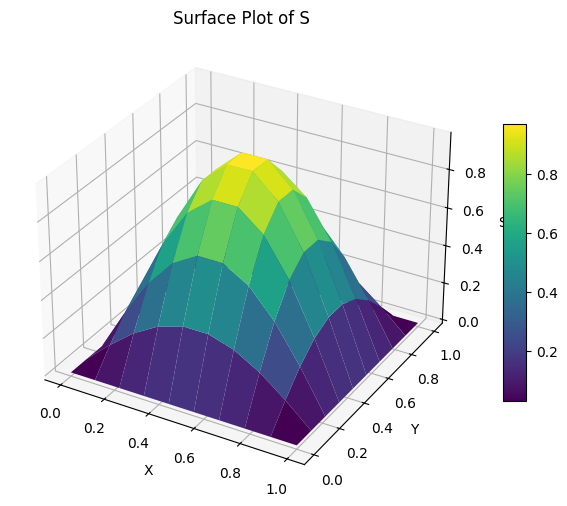

In [162]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, S, cmap="viridis")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("S")
ax.set_title("Surface Plot of S")
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12)
plt.show()


Max error: 4.736418e-06
Mean error: 1.547569e-07
RMS error: 5.173506e-07


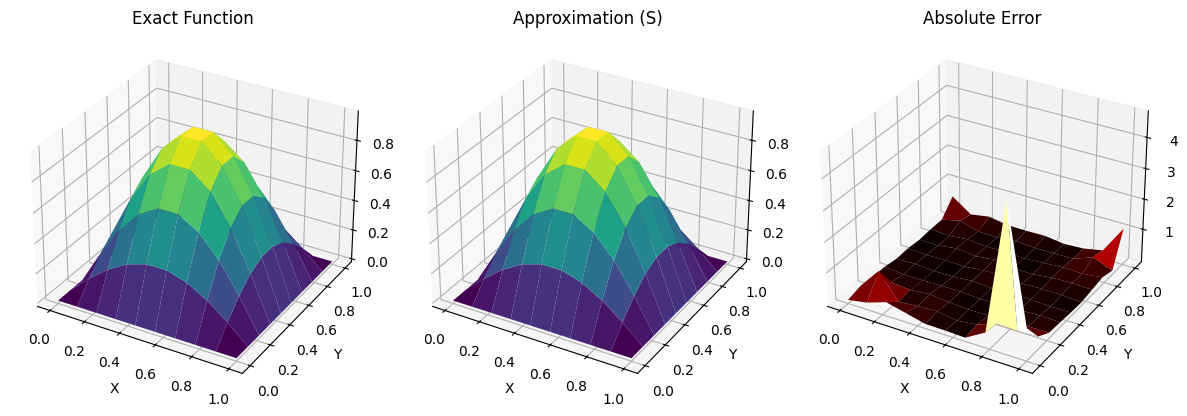

In [163]:
# Compute exact values at evaluation points
f_exact = np.sin(np.pi * X) * np.sin(np.pi * Y)

# Calculate error
error = np.abs(S - f_exact)

# Print error statistics
print(f"Max error: {np.max(error):.6e}")
print(f"Mean error: {np.mean(error):.6e}")
print(f"RMS error: {np.sqrt(np.mean(error**2)):.6e}")

# Visualize the error
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131, projection="3d")
surf1 = ax1.plot_surface(X, Y, f_exact, cmap="viridis")
ax1.set_title("Exact Function")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("f")

ax2 = fig.add_subplot(132, projection="3d")
surf2 = ax2.plot_surface(X, Y, S, cmap="viridis")
ax2.set_title("Approximation (S)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("S")

ax3 = fig.add_subplot(133, projection="3d")
surf3 = ax3.plot_surface(X, Y, error, cmap="hot")
ax3.set_title("Absolute Error")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Error")

plt.tight_layout()
plt.show()

RBF-RA  optimal epsilon: 1.0200, Relative error: 2.744847e-07
RBF-Direct optimal epsilon: 0.8000, Relative error: 1.469226e-07


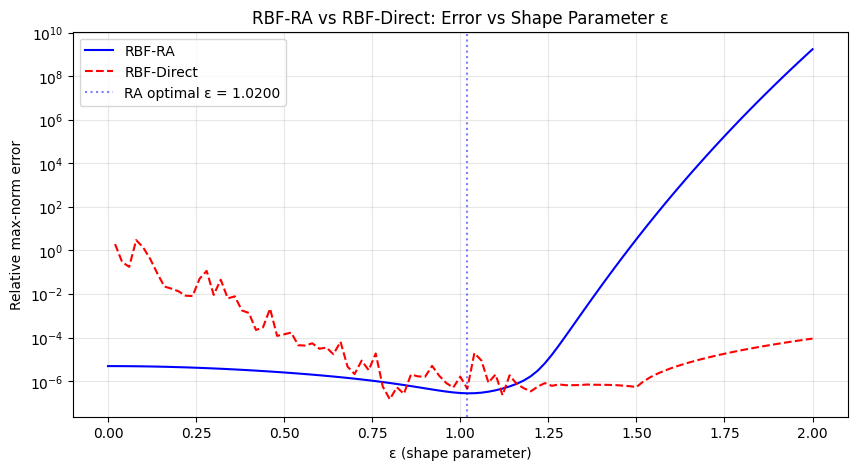

In [166]:
# Error vs epsilon: find the optimal shape parameter
epsilons = np.linspace(0, 2, 101)
eval_eps = epsilons / Er
R_all = EvalRA(a, b, eval_eps)  # (M, 101)

# Exact values at eval points (flattened)
f_exact_flat = np.sin(np.pi * eval_points[:, 0]) * np.sin(np.pi * eval_points[:, 1])

# RBF-RA relative max-norm error for each epsilon
errors_ra = np.array([
    np.max(np.abs(R_all[:, i] - f_exact_flat)) / np.max(np.abs(f_exact_flat))
    for i in range(R_all.shape[1])
])

# RBF-Direct relative max-norm error for each epsilon (real-valued, standard solve)
errors_direct = []
for eps in epsilons:
    if eps == 0:
        errors_direct.append(np.nan)  # RBF-Direct undefined at eps=0
    else:
        try:
            A = GenPhi(nodes, eps)
            lam = np.linalg.solve(A, f)
            Phi_eval = GenEvalPhi(eval_points, nodes, eps)
            s_direct = Phi_eval @ lam
            err = np.max(np.abs(s_direct - f_exact_flat)) / np.max(np.abs(f_exact_flat))
            errors_direct.append(err)
        except np.linalg.LinAlgError:
            errors_direct.append(np.nan)
errors_direct = np.array(errors_direct)

best_idx = np.argmin(errors_ra)
print(f"RBF-RA  optimal epsilon: {epsilons[best_idx]:.4f}, Relative error: {errors_ra[best_idx]:.6e}")
best_direct = np.nanargmin(errors_direct)
print(f"RBF-Direct optimal epsilon: {epsilons[best_direct]:.4f}, Relative error: {errors_direct[best_direct]:.6e}")

plt.figure(figsize=(10, 5))
plt.semilogy(epsilons, errors_ra, 'b-', linewidth=1.5, label='RBF-RA')
plt.semilogy(epsilons, errors_direct, 'r--', linewidth=1.5, label='RBF-Direct')
plt.axvline(epsilons[best_idx], color='b', linestyle=':', alpha=0.5, label=f'RA optimal ε = {epsilons[best_idx]:.4f}')
plt.xlabel('ε (shape parameter)')
plt.ylabel('Relative max-norm error')
plt.title('RBF-RA vs RBF-Direct: Error vs Shape Parameter ε')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()
